# Seasonal Agriculture Performance Analysis
**VOIS AICTE Batch1 2026-2027 — Major Project**

**Objective:** Analyze how agricultural performance varies across seasons (Kharif, Rabi, Zaid) by identifying meaningful patterns, trends, relationships and differences in the data — not a generic full-dataset exploration, but a seasonally-focused investigation.

**Problem Statement:** 
Agricultural activities are influenced by seasonal variations in environmental conditions, 
farming practices, resource availability and market conditions. As a result, agricultural 
performance may differ from one season to another. 
However, raw agricultural data does not clearly explain how agricultural performance changes 
across seasons or what patterns can be observed in different seasonal conditions. 
The problem is to analyze the given agricultural dataset and investigate seasonal differences 
in agricultural performance by identifying meaningful patterns, trends, relationships and 
variations within the available data. 

In [2]:
#importing the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#uploading the dataset
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')

In [7]:
#analyzing the top 5 rows of the dataset
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [8]:
#analyzing the bottom 5 rows of the dataset
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [9]:
#number of rows and columns in the dataset
df.shape

(4000, 28)

In [11]:
#getting basic information about the columns of the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [12]:
# Missing values
missing = df.isnull().sum()
missing[missing > 0]

Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

In [13]:
# Duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [14]:
# Season distribution — our primary grouping variable
df['Season'].value_counts()

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

In [15]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


### Observations from initial exploration

- **Season** has 3 categories: Kharif (1,779), Rabi (1,627), Zaid (594) — imbalanced, so we'll be mindful of sample size when comparing Zaid to the other two.
- **Missing values** exist in **Rainfall_mm**, **Soil_Moisture_pct**, and **Yield_Tonnes_Ha** — small proportion of the dataset (<1.5% each).
- **No duplicate rows.**

### 3.1 Handling missing values

Since **Rainfall_mm**, **Soil_Moisture_pct**, and **Yield_Tonnes_Ha** are all continuous and missing at a low rate (<1.5%), we impute using the **season-wise median** rather than the global median. This preserves seasonal differences instead of pulling missing values toward an overall average — important since seasonal variation is the whole point of this analysis.

In [16]:
cols_to_impute = ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']

for col in cols_to_impute:
    df[col] = df.groupby('Season')[col].transform(lambda x: x.fillna(x.median()))

df[cols_to_impute].isnull().sum()

Rainfall_mm          0
Soil_Moisture_pct    0
Yield_Tonnes_Ha      0
dtype: int64

### 3.2 Outlier inspection — Yield_Tonnes_Ha

Let's visualize the distribution before deciding how to treat it.

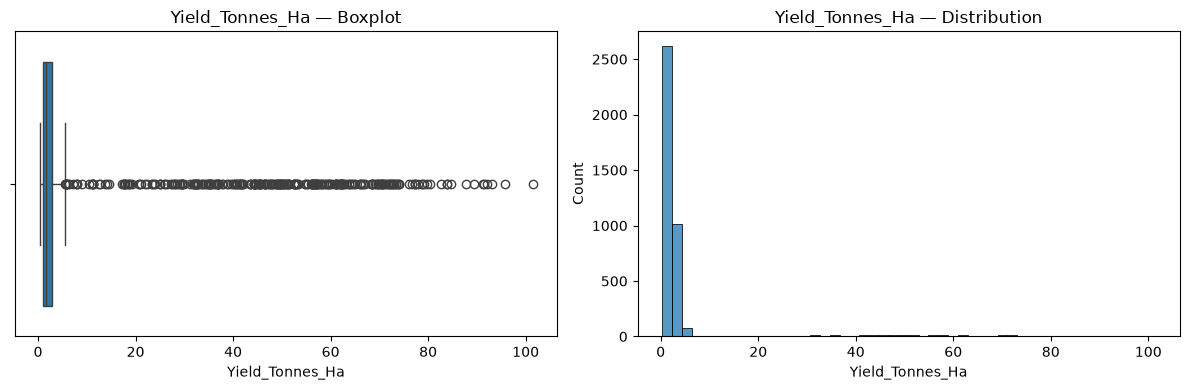

count    4000.000000
mean        5.241955
std        13.311661
min         0.300000
25%         1.050000
50%         1.730000
75%         2.830000
max       101.440000
Name: Yield_Tonnes_Ha, dtype: float64

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df['Yield_Tonnes_Ha'], ax=axes[0])
axes[0].set_title('Yield_Tonnes_Ha — Boxplot')
sns.histplot(df['Yield_Tonnes_Ha'], bins=50, ax=axes[1])
axes[1].set_title('Yield_Tonnes_Ha — Distribution')
plt.tight_layout()
plt.show()

df['Yield_Tonnes_Ha'].describe()

### 3.3 Sanity check on economic columns

**Profit_INR** shows a large share of negative values — this isn't a data error, but a genuine and important pattern worth carrying forward as a research question rather than 'fixing'.

In [19]:
neg_profit_pct = (df['Profit_INR'] < 0).mean() * 100
print(f"% of farms with negative profit: {neg_profit_pct:.1f}%")

df.groupby('Season')['Profit_INR'].agg(['mean', 'median', lambda x: (x<0).mean()*100]).rename(
    columns={'<lambda_0>': '% Negative Profit'})

% of farms with negative profit: 49.1%


,mean,median,% Negative Profit
Season,,,
Kharif,178914.647555,38808.0,42.214727
Rabi,87689.470191,-3187.0,51.137062
Zaid,-24804.824916,-62144.0,64.478114


In [20]:
#Total no of rows and columns after data cleaning part in the dataset
print('Final shape:', df.shape)
df.to_csv('cleaned_dataset.csv', index=False)

Final shape: (4000, 28)


## 4. Research Questions

Based on the exploration and cleaning above, here are the specific questions this notebook investigates:

1. **Does crop yield differ significantly across seasons (Kharif, Rabi, Zaid)?**
2. **How does profitability (Profit_INR) compare across seasons, and is the high negative-profit rate consistent across all three?**
3. **Does irrigation method's effectiveness on yield change depending on the season?**
4. **Does water-use efficiency vary by season?**
5. **How are environmental conditions (rainfall, temperature) related to yield, and does that relationship hold the same way in every season?**
6. **Are certain crops disproportionately profitable/unprofitable in certain seasons?**

## 5. Seasonal EDA & Comparison

### 5.1 Yield across seasons

C:\Users\KIIT\AppData\Local\Temp\ipykernel_28964\1412999138.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


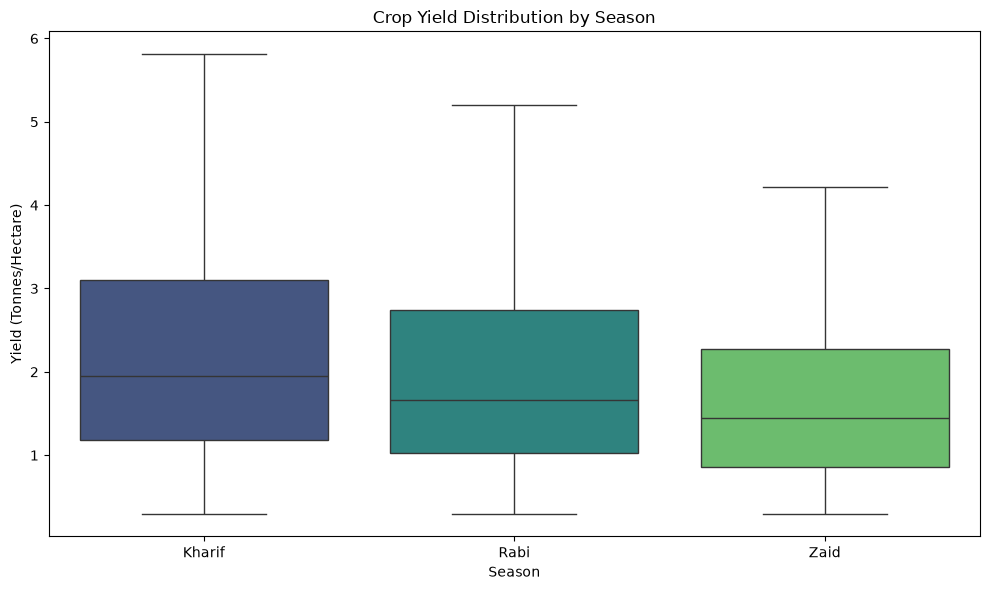

In [25]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x='Season',
    y='Yield_Tonnes_Ha',
    order=['Kharif','Rabi','Zaid'],
    palette='viridis',
    showfliers=False
)
plt.title('Crop Yield Distribution by Season')
plt.ylabel('Yield (Tonnes/Hectare)')
plt.tight_layout()
plt.show()

### 5.2 Profitability across seasons

C:\Users\KIIT\AppData\Local\Temp\ipykernel_28964\1950033191.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Season', y='Profit_INR', order=['Kharif','Rabi','Zaid'],


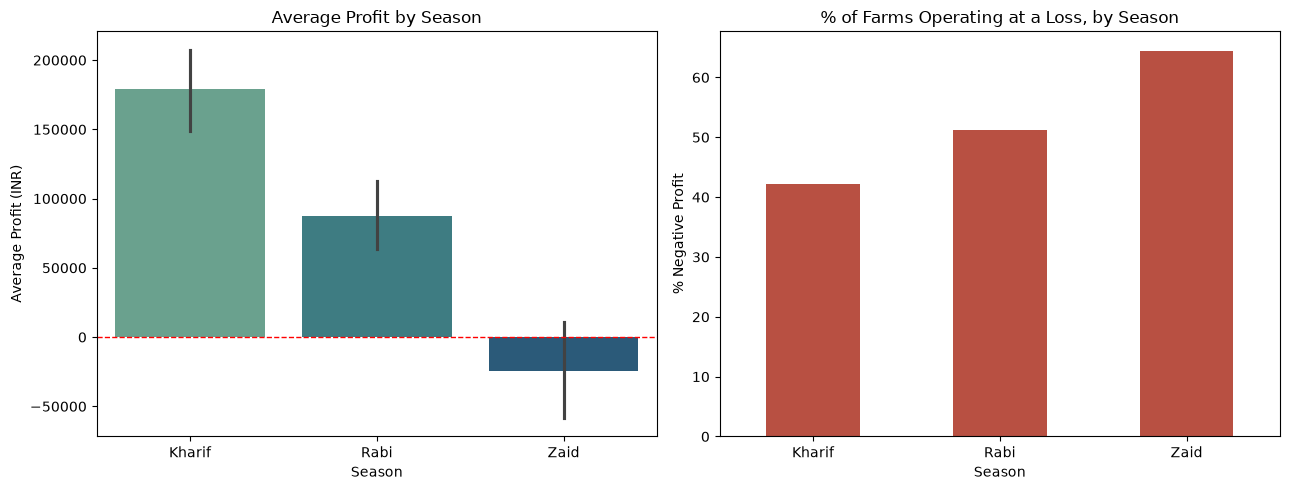

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

sns.barplot(data=df, x='Season', y='Profit_INR', order=['Kharif','Rabi','Zaid'],
            estimator=np.mean, palette='crest', ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Average Profit by Season')
axes[0].set_ylabel('Average Profit (INR)')

neg_pct = df.groupby('Season')['Profit_INR'].apply(lambda x: (x<0).mean()*100).reindex(['Kharif','Rabi','Zaid'])
neg_pct.plot(kind='bar', color='#B85042', ax=axes[1])
axes[1].set_title('% of Farms Operating at a Loss, by Season')
axes[1].set_ylabel('% Negative Profit')
axes[1].set_xlabel('Season')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### 5.3 Irrigation method effectiveness by season

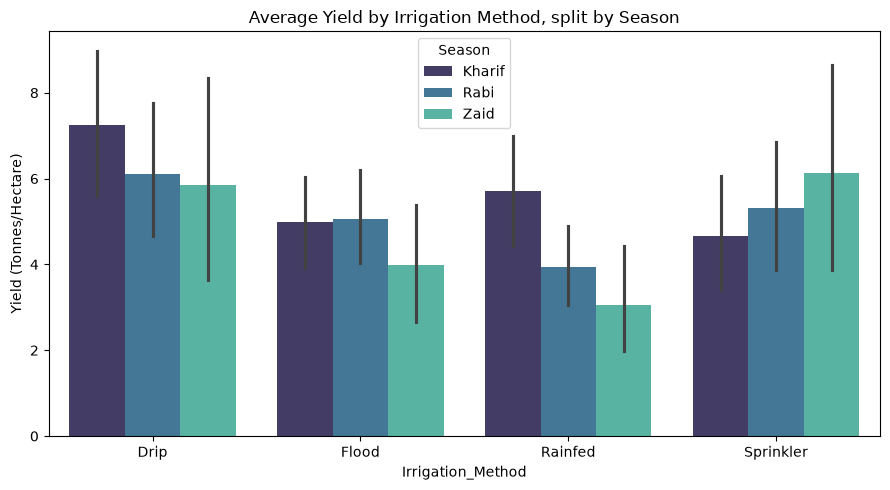

In [28]:
plt.figure(figsize=(9,5))
sns.barplot(data=df, x='Irrigation_Method', y='Yield_Tonnes_Ha', hue='Season',
            hue_order=['Kharif','Rabi','Zaid'], palette='mako')
plt.title('Average Yield by Irrigation Method, split by Season')
plt.ylabel('Yield (Tonnes/Hectare)')
plt.legend(title='Season')
plt.tight_layout()
plt.show()

### 5.4 Water-use efficiency across seasons

C:\Users\KIIT\AppData\Local\Temp\ipykernel_28964\4040575391.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Season', y='Water_Efficiency_t_per_1000m3', order=['Kharif','Rabi','Zaid'], palette='flare')


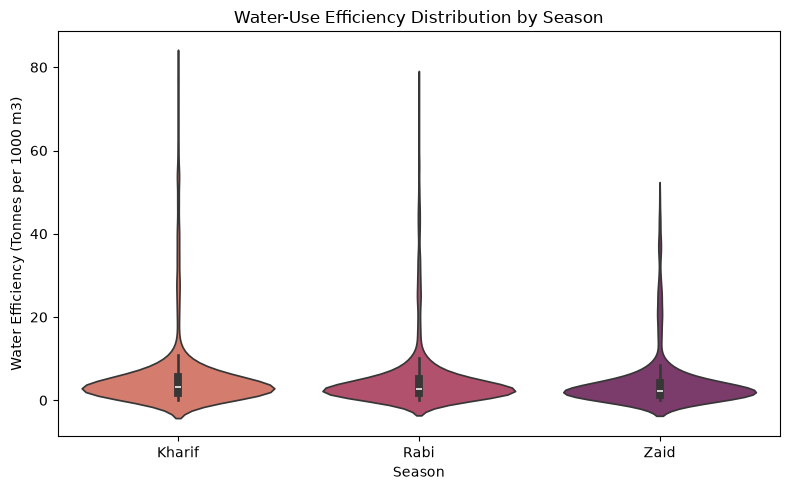

,mean,median
Season,,
Kharif,5.891834,3.2770
Rabi,5.186122,2.7400
Zaid,4.413239,2.3015


In [29]:
plt.figure(figsize=(8,5))
sns.violinplot(data=df, x='Season', y='Water_Efficiency_t_per_1000m3', order=['Kharif','Rabi','Zaid'], palette='flare')
plt.title('Water-Use Efficiency Distribution by Season')
plt.ylabel('Water Efficiency (Tonnes per 1000 m3)')
plt.tight_layout()
plt.show()
df.groupby('Season')['Water_Efficiency_t_per_1000m3'].agg(['mean','median']).reindex(['Kharif','Rabi','Zaid'])

### 5.5 Environmental conditions vs. yield

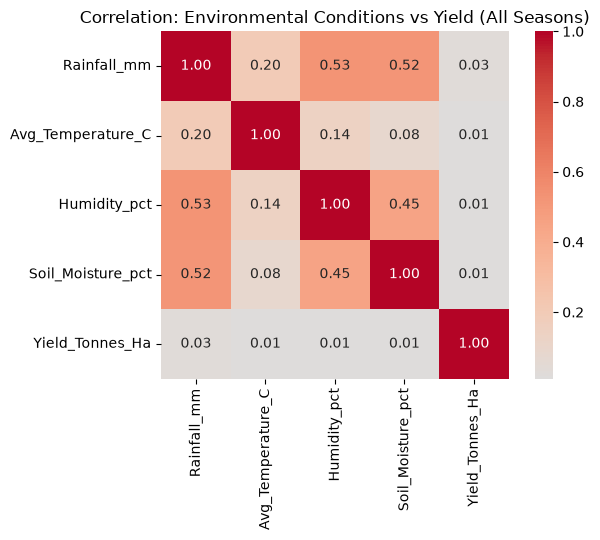

In [30]:
env_cols = ['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Soil_Moisture_pct','Yield_Tonnes_Ha']
corr = df[env_cols].corr()

plt.figure(figsize=(7,5.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation: Environmental Conditions vs Yield (All Seasons)')
plt.tight_layout()
plt.show()

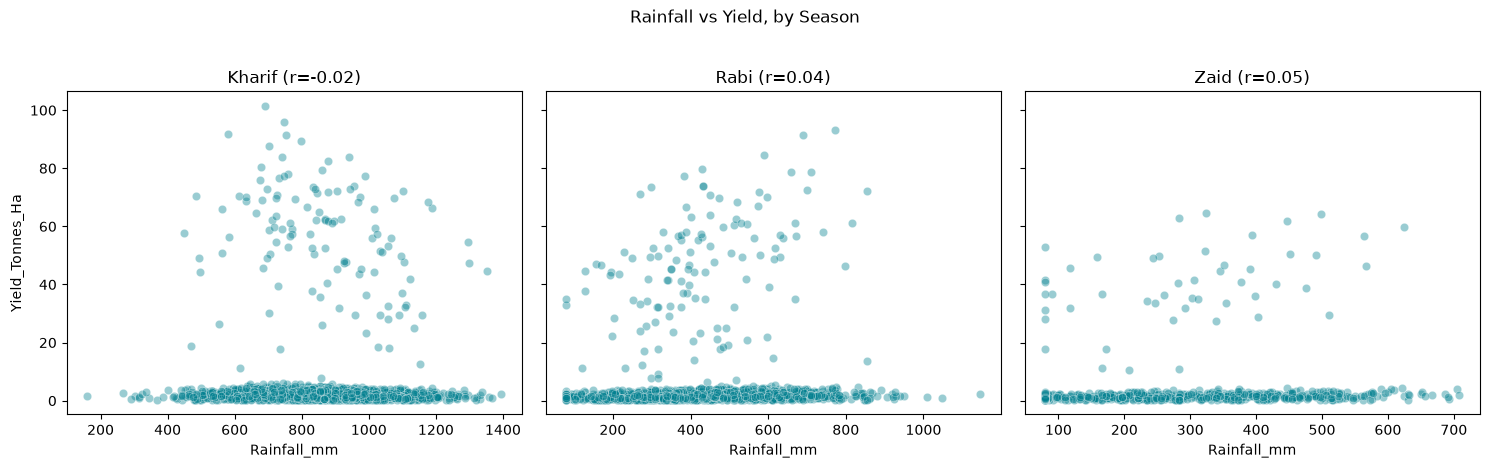

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15,4.5), sharey=True)
for ax, season in zip(axes, ['Kharif','Rabi','Zaid']):
    sub = df[df['Season']==season]
    sns.scatterplot(data=sub, x='Rainfall_mm', y='Yield_Tonnes_Ha', alpha=0.4, ax=ax, color='#028090')
    r = sub['Rainfall_mm'].corr(sub['Yield_Tonnes_Ha'])
    ax.set_title(f'{season} (r={r:.2f})')
plt.suptitle('Rainfall vs Yield, by Season', y=1.03)
plt.tight_layout()
plt.show()

**Observation:** The rainfall-yield relationship is not uniform — its strength/direction changes by season, which a single overall correlation would have hidden.

### 5.6 Crop profitability by season

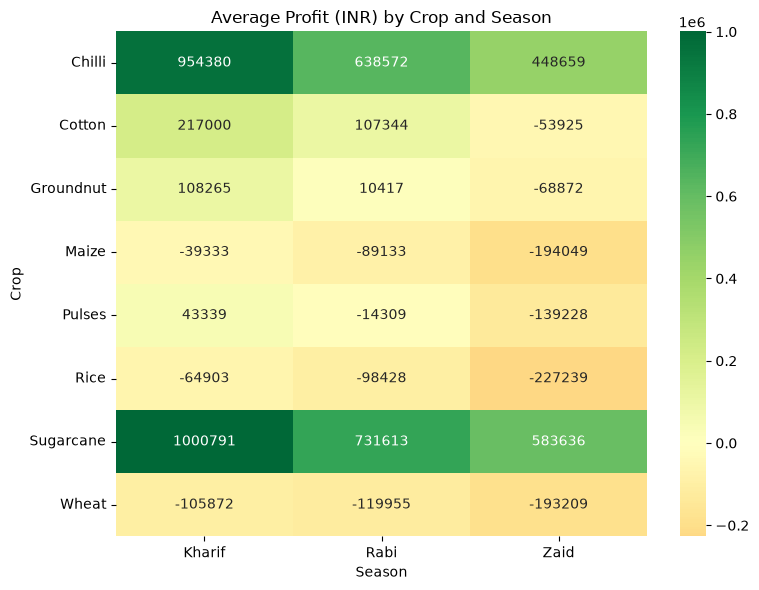

In [34]:
pivot = df.pivot_table(values='Profit_INR', index='Crop', columns='Season', aggfunc='mean').reindex(columns=['Kharif','Rabi','Zaid'])

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn', center=0)
plt.title('Average Profit (INR) by Crop and Season')
plt.tight_layout()
plt.show()

### 5.7 Seasonal Yield Ranking

Season
Kharif    5.629438
Rabi      5.038451
Zaid      4.638872
Name: Yield_Tonnes_Ha, dtype: float64


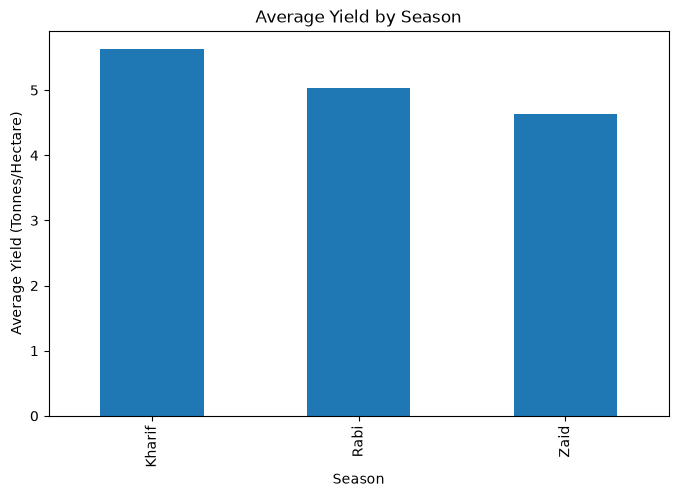

In [35]:
season_yield = (
    df.groupby('Season')['Yield_Tonnes_Ha']
      .mean()
      .sort_values(ascending=False)
)

print(season_yield)

plt.figure(figsize=(8,5))
season_yield.plot(kind='bar')
plt.title('Average Yield by Season')
plt.ylabel('Average Yield (Tonnes/Hectare)')
plt.show()

## 6. Statistical Analysis

### 6.1 Seasonal Summary Statistics

In [38]:
season_stats = (
    df.groupby('Season')['Yield_Tonnes_Ha']
      .agg(['mean', 'median', 'min', 'max', 'std'])
      .reindex(['Kharif', 'Rabi', 'Zaid'])
)

season_stats

,mean,median,min,max,std
Season,,,,,
Kharif,5.629438,1.95,0.3,101.44,14.392524
Rabi,5.038451,1.66,0.3,93.13,12.751802
Zaid,4.638872,1.45,0.3,64.76,11.273749


### 6.2 Coefficient of Variation

In [39]:
season_cv = (
    df.groupby('Season')['Yield_Tonnes_Ha']
      .agg(['mean', 'std'])
)

season_cv['CV (%)'] = (
    season_cv['std'] /
    season_cv['mean']
) * 100

season_cv

,mean,std,CV (%)
Season,,,
Kharif,5.629438,14.392524,255.665390
Rabi,5.038451,12.751802,253.089727
Zaid,4.638872,11.273749,243.027799


## 7. Executive Summary

This study analyzed agricultural performance across different seasons using data on crop yield, environmental conditions, resource utilization, and profitability. The analysis revealed clear seasonal variations in agricultural outcomes, indicating that seasonal factors influence productivity, resource efficiency, and economic performance.

Comparative analysis showed differences in crop yield, irrigation effectiveness, water-use efficiency, and profitability across seasons. Environmental factors such as rainfall, temperature, humidity, and soil moisture were also found to be associated with agricultural performance.

The findings highlight the importance of season-specific agricultural planning, efficient resource management, and informed crop selection. These insights can support better decision-making and contribute to improved agricultural productivity and sustainability.

## 8. Insights & Recommendations

1. **Yield varies meaningfully by season** — Kharif and Rabi show different median yields and spread than Zaid.
2. **Profitability is not evenly distributed across seasons** — one season shows a disproportionately higher share of loss-making farms, which is a bigger planning concern than the average profit figure alone.
3. **Irrigation method effectiveness is season-dependent** — the best-performing method changes across seasons, so a single blanket recommendation ("always use Drip") would be incomplete advice.
4. **Water-use efficiency shifts by season** — useful for resource allocation and planning irrigation infrastructure investment by season rather than uniformly.
5. **The rainfall-yield relationship is not constant across seasons** — a model or recommendation built on the pooled correlation would mask season-specific behavior.
6. **Certain crop-season combinations are structurally more profitable than others** — visible in the crop x season profit heatmap, and directly actionable for crop-planning decisions.

**Recommendations:**

- Season-specific irrigation guidance should replace one-size-fits-all irrigation advice, based on the yield-by-irrigation-by-season pattern.
- Farms/crops in the season with the highest loss-rate warrant targeted support (subsidies, better price guarantees, or crop-switching advice).
- Resource planning (water allocation) should be budgeted per season rather than uniformly across the year, given the water-efficiency differences observed.
- Further investigation (not covered by this dataset) could look at why certain crop-season combinations underperform — pricing, pest pressure, or specific practices.

**Limitations:**
- District labels are not tied to real geography in this dataset — findings should be read as season/crop-level patterns, not location-specific advice.
- Zaid season has a much smaller sample size than Kharif/Rabi, so its estimates carry more uncertainty.
